## 1. Data processine

In [1]:
import sys
sys.path.append('../')
from fluProfiler_models import fluProfiler_Config, fluProfiler_HANA
from transformers import get_linear_schedule_with_warmup
from huggingface_hub import InferenceApi
from utilities import assign_season
from tqdm import tqdm
import json
import torch
import pandas as pd
import torch.nn.functional as F
import numpy as np
from utilities import load_embedding, EarlyStopping
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from datetime import datetime
import pickle
from utilities import print_exams
import matplotlib.pyplot as plt
import os
import torch
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
import multiprocessing
from scipy.stats import hypergeom

class fluProfiler_Dataset(Dataset):
    def __init__(self, DataFrame):
        self.emb_file_name_a = ('matrix_' + DataFrame['seq_id_a']).tolist()
        self.emb_file_name_b = ('matrix_' + DataFrame['seq_id_b']).tolist()
        self.emb_file_name_c = ('matrix_' + DataFrame['seq_id_c']).tolist()
        self.emb_file_name_d = ('matrix_' + DataFrame['seq_id_d']).tolist()

        self.strainPassCats = convert_Pass2tensor(('<cls>' + DataFrame['serumPassCat'] + '<eos>' + DataFrame['virusPassCat'] + '<eos>').tolist())

        self.labels = torch.tensor(DataFrame['label'].tolist())
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.emb_file_name_a[idx], self.emb_file_name_b[idx], self.emb_file_name_c[idx], self.emb_file_name_d[idx], \
               self.strainPassCats[idx], self.labels[idx]

def convert_Pass2tensor(pass_cats):
    result = [
        item.replace('<cls>', '0').replace('<eos>', '1').replace('<EGG>', '2').replace('<CELL>', '3').replace('<BOTH>', '4')
        for item in pass_cats
    ]
    result = torch.tensor([[int(number) for number in [char for char in item]] for item in result])
    return result

def generate_matrix(matrix_list):
    seq_len = [mat.shape[0] for mat in matrix_list]
    max_len = max(seq_len)
    mask_list = []
    for i in range(len(matrix_list)): 
        matrix_list[i] = F.pad(matrix_list[i], (0, 0, 0, max_len - seq_len[i]))
        mask = torch.concat((torch.ones(1,seq_len[i]),torch.zeros(1,max_len-seq_len[i])),axis=1)
        mask_list.append(mask)
    matrix = torch.stack(matrix_list)
    mask = torch.stack(mask_list).view(len(matrix_list),max_len)
    return matrix, mask

def list2df(mylist, period):
    merged_rows = []
    for i in range(0, len(mylist), period):
        merged_row = []
        for j in range(period):
            merged_row += mylist[i + j]
        merged_rows.append(merged_row)

    return pd.DataFrame(merged_rows)

def get_top_k_indices(arr, k):
    # 将列表转换为numpy数组
    np_arr = np.array(arr)
    # 按值降序排序并获取前k个索引
    top_k_indices = np_arr.argsort()[-k:][::-1]
    return top_k_indices.tolist()

def custom_sort_key(item, order_list):
    try:
        return order_list.index(item)
    except ValueError:
        return len(order_list)

def sort_list_by_another_list(list1, list2):
    return sorted(list1, key=lambda x: custom_sort_key(x, list2))
    

In [2]:
## 以HA1的第一个位点开始计数的位点
epitope_A = [122,124,126,131,133,134,135,136,137,138,139,140,142,143,144,145,146]
epitope_B = [128,155,156,157,158,159,160,163,164,165,186,187,188,189,190,191,192,193,194,195,196,197,198]
epitope_C = [45,48,50,51,52,53,54,55,56,275,276,278,279,285,299,307,312]
epitope_D = [121,171,172,173,174,201,207,208,209,213,217,219,220,226,227,242,244,247,248]
epitope_E = [57,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,88,92,94,260,261,262]
Unknown = [2,3,5,25,33,106,202,222,225,271]

epitope_All = epitope_A + epitope_B + epitope_C + epitope_D + epitope_E + Unknown

In [3]:
device = torch.device("cuda:3")
model = torch.load('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/trained_model/1.7_Artificial_back/2025-08-19_17-43-32.pth', weights_only=False, map_location=device)

In [4]:
group_columns = ['seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat']
new_columns = ['seq_id_a', 'seq_id_b', 'seq_id_c', 'seq_id_d','seq_a', 'seq_b', 'seq_c', 'seq_d', 
               'serumPassCat', 'virusPassCat', 'serumName', 'virusName', 'label']
data_path = '/data/chenyihao/dataset'
Crick_all = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/all.csv')
agg_dict = {c: 'first' for c in Crick_all.columns if c not in group_columns}
agg_dict['label'] = 'mean'
Crick_all_final = Crick_all.groupby(group_columns).agg(agg_dict).reset_index()
train_data, test_data = train_test_split(Crick_all_final, test_size=0.1, random_state=42)
train_data, valid_data = train_test_split(train_data, test_size=1/9, random_state=42)

## meta information
Crick_H1N1 = pd.read_excel('../../data/raw/data4model(Crick-H1N1).xlsx')
Crick_H3N2 = pd.read_excel('../../data/raw/data4model(Crick-H3N2).xlsx')
Crick_dt = pd.concat([Crick_H1N1, Crick_H3N2], axis=0)
Crick_dt['serumPassCat'] = '<' + Crick_dt['serumPassCat'] + '>'
Crick_dt['virusPassCat'] = '<' + Crick_dt['virusPassCat'] + '>'
Crick_dt.drop_duplicates(subset=['serumHA','serumNA','virusHA','virusNA','serumPassCat','virusPassCat','serumName','virusName'], inplace=True)

In [5]:
Crick_dt = Crick_dt.drop(columns=['serumDate','virusDate'])

In [19]:
## select contact sequences
Inference_data_filt1 = train_data[(train_data['seq_a'].str.len() == 566) &
                            (train_data['seq_b'].str.len() == 469) &
                            (train_data['seq_c'].str.len() == 566) &
                            (train_data['seq_d'].str.len() == 469)]
## obtain meta information and assign season
selected_columns = ['seq_id_a', 'seq_id_b', 'seq_id_c', 'seq_id_d', 'seq_a','seq_b','seq_c','seq_d',
                    'serumPassCat','virusPassCat','serumName','virusName', 'virusType', 'virusDate', 'label']
Inference_data_filt2=Inference_data_filt1.merge(Crick_dt, left_on=['seq_a','seq_b','seq_c','seq_d','serumPassCat','virusPassCat','serumName','virusName'], 
                                      right_on=['serumHA','serumNA','virusHA','virusNA','serumPassCat','virusPassCat','serumName','virusName'],how='left')[selected_columns]
Inference_data_filt2 = Inference_data_filt2.loc[~Inference_data_filt2['virusDate'].isnull()]
Inference_data_filt2['virusDate'] = Inference_data_filt2['virusDate'].apply(assign_season)
## select H3N2
Inference_data_filt3 = Inference_data_filt2[Inference_data_filt2['virusType'] == 'H1N1']
# Inference_data_filt3 = Inference_data_filt2[Inference_data_filt2['virusType'] == 'H3N2']

Inference_data_final = Inference_data_filt3
Inference_dataset = fluProfiler_Dataset(Inference_data_final)
Inference_dataloader = DataLoader(Inference_dataset, batch_size=200, shuffle=False)

### 1.2 attention prob inference

In [81]:
import os
from tqdm import tqdm

# load embedding
emb_df = Inference_data_final
sequence_names = pd.concat([emb_df['seq_id_a'], emb_df['seq_id_b'], emb_df['seq_id_c'], emb_df['seq_id_d']]).unique().tolist()
sequence_names = ['matrix_' + item + '.pt' for item in sequence_names]
emb_dict = load_embedding("/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/embedding_Crick", files=sequence_names)
emb_dict = {key: value.to(device) for key, value in emb_dict.items()}

Loading tensor: 100%|██████████| 4432/4432 [11:49<00:00,  6.24file/s]


In [82]:
test_prediction_ls = []
test_reference_ls = []
test_logits_ls = []
model.eval()
for batch in Inference_dataloader:
    with torch.no_grad():
        emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
        
        matrixs_a, masks_a = generate_matrix([emb_dict[key] for key in emb_file_name_a])
        matrixs_b, masks_b = generate_matrix([emb_dict[key] for key in emb_file_name_b])
        matrixs_c, masks_c = generate_matrix([emb_dict[key] for key in emb_file_name_c])
        matrixs_d, masks_d = generate_matrix([emb_dict[key] for key in emb_file_name_d])
        
        # matrixs_a = matrixs_a.to(device)
        # matrixs_b = matrixs_b.to(device)
        # matrixs_c = matrixs_c.to(device)
        # matrixs_d = matrixs_d.to(device)

        masks_a = masks_a.to(device)
        masks_b = masks_b.to(device)
        masks_c = masks_c.to(device)
        masks_d = masks_d.to(device)
        
        strainPassCats = strainPassCats.to(device)
        
        labels = labels.to(device)
        
        with torch.no_grad():
            loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, matrices_d=matrixs_d, 
                                         matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, 
                                         matrix_attention_masks_c=masks_c, matrix_attention_masks_d=masks_d, 
                                         strainPassCats=strainPassCats, labels=labels,save_attention_path='/mnt/zzbnew/peixunban/chenyihao/attention_prob_H1N1/')
        
        test_prediction_ls = test_prediction_ls + output.view(-1).tolist()
        test_reference_ls = test_reference_ls + labels.tolist()
        test_logits_ls.append(logits.tolist())

result = print_exams(test_prediction_ls, test_reference_ls)

MAE: 0.43420
MSE: 0.31198
pearson correlation: 0.95092
spearman correlation: 0.88859
R2_score: 0.90195


## 2. HA protein

### 2.0 Data loading

In [7]:
from concurrent.futures import ThreadPoolExecutor
import torch, multiprocessing
from tqdm import tqdm

data_dir = "/mnt/zzbnew/peixunban/chenyihao/attention_prob"
files = [f"{data_dir}/{i}.pth" for i in range(3, 409, 4)]

def load_file(path):
    return torch.load(path, map_location="cpu", weights_only=True)

max_workers = min(8, multiprocessing.cpu_count())

attention_prob = [None] * len(files)
with ThreadPoolExecutor(max_workers=max_workers) as executor:
    futures = {executor.submit(load_file, f): idx for idx, f in enumerate(files)}
    for future in tqdm(as_completed(futures), total=len(futures)):
        idx = futures[future]
        attention_prob[idx] = future.result()

long_list = [t for tensor in attention_prob for t in tensor]
virusHAtensor = torch.stack(long_list).detach().numpy()


100%|██████████| 102/102 [01:24<00:00,  1.21it/s]


### 2.1 diversity

In [16]:
# # 初始化一个空列表，用于存储每个位置上的字符多样性
series = Inference_data_final['seq_c']
diversity_list = []

# 遍历字符串的每个位置
for i in range(len(series.iloc[0])):
    chars = series.apply(lambda x: x[i])
    mean = chars.value_counts().mean()
    std = chars.value_counts().std()
    diversity = std / mean if mean != 0 else 0
    diversity_list.append(diversity)

for i in range(len(diversity_list)):
    if np.isnan(diversity_list[i]):
        diversity_list[i] = 0

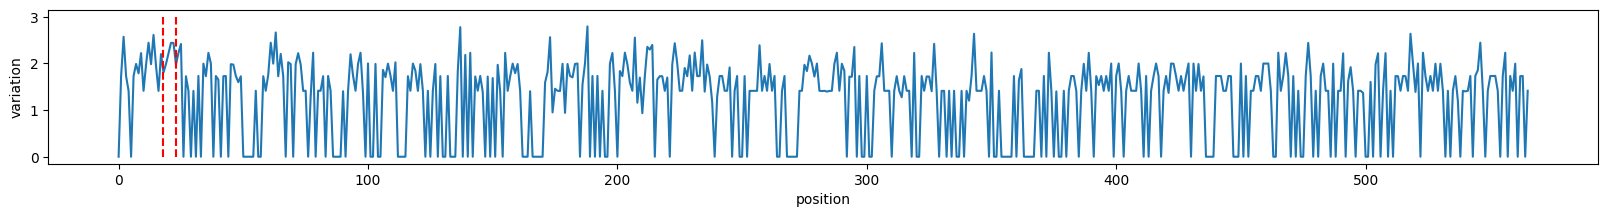

In [130]:
plt.figure(figsize=(20, 2))
plt.plot(diversity_list)
plt.xlabel('position')
plt.ylabel('variation')
plt.vlines(x=6+17, ymin=0, ymax=3, colors='red', linestyles='dashed')
plt.vlines(x=18, ymin=0, ymax=3, colors='red', linestyles='dashed')

### 2.2 Key sites

#### 2.2.1 important site

In [11]:
# seasons = [f"{year}{hemi}" for year in range(2006, 2024) for hemi in ["NH", "SH"]]
seasons = [f"{year}{hemi}" for year in range(2014, 2024) for hemi in ["NH", "SH"]]
           
# 一次性计算第三维均值
virus_mean = virusHAtensor.mean(2)
# 预先转换为数组
virus_dates = np.array(Inference_data_final['virusDate'])
# 初始化输出矩阵（假设virusHAtensor.shape[1]是site维度）
n_sites = virus_mean.shape[1]
Site_scores = np.zeros((n_sites, len(seasons)))

# 向量化循环
for i, season in enumerate(seasons):
    mask = (virus_dates == season)
    if not np.any(mask):
        continue
    Site_scores[:, i] = virus_mean[mask].mean(0)

In [12]:
Sites_origin = []
for i in range(Site_scores.shape[1]):
    site = get_top_k_indices(Site_scores[17:346,i], k=15)
    site = [item + 1 for item in site]
    Sites_origin = Sites_origin + site

Sites = sorted(set(Sites_origin))
print(Sites)

print('extracted Sites:', len(Sites))
print('Sites in reported epitope:', len(set(Sites) & set(epitope_All)))
print('Sites in epitope A:', len(set(Sites) & set(epitope_A)))
print('Sites in epitope B:', len(set(Sites) & set(epitope_B)))

[4, 5, 6, 8, 50, 51, 79, 94, 107, 131, 133, 137, 138, 140, 141, 142, 144, 145, 146, 156, 158, 159, 160, 161, 174, 186, 187, 188, 189, 190, 194, 206, 219, 222, 267]
extracted Sites: 35
Sites in reported epitope: 27
Sites in epitope A: 9
Sites in epitope B: 10


In [66]:
from functools import reduce

season_sites = [Sites_origin[i:i+15] for i in range(0, len(Sites_origin), 15)]
common_sites = list(reduce(lambda a, b: set(a) & set(b), season_sites))
print(sorted(common_sites))

[158, 159, 188, 194, 206, 267]


In [7]:
from scipy.stats import fisher_exact

# 输入数据
k_AB = 19      # AB 命中数
L_AB = len(epitope_A) + len(epitope_B)     # AB 区域长度
k_CDE = 6      # CDE 命中数
L_CDE = len(epitope_C) + len(epitope_D) + len(epitope_E)     # CDE 区域长度

# 构造 2×2 表
table = [[k_AB, L_AB - k_AB],
         [k_CDE, L_CDE - k_CDE]]

# 单侧检验（AB 比 CDE 更富集）
oddsratio, p_one_sided = fisher_exact(table, alternative='greater')

print(f'Odds ratio = {oddsratio:.3f}, one-sided P = {p_one_sided:.3e}')


Odds ratio = 8.897, one-sided P = 1.240e-05


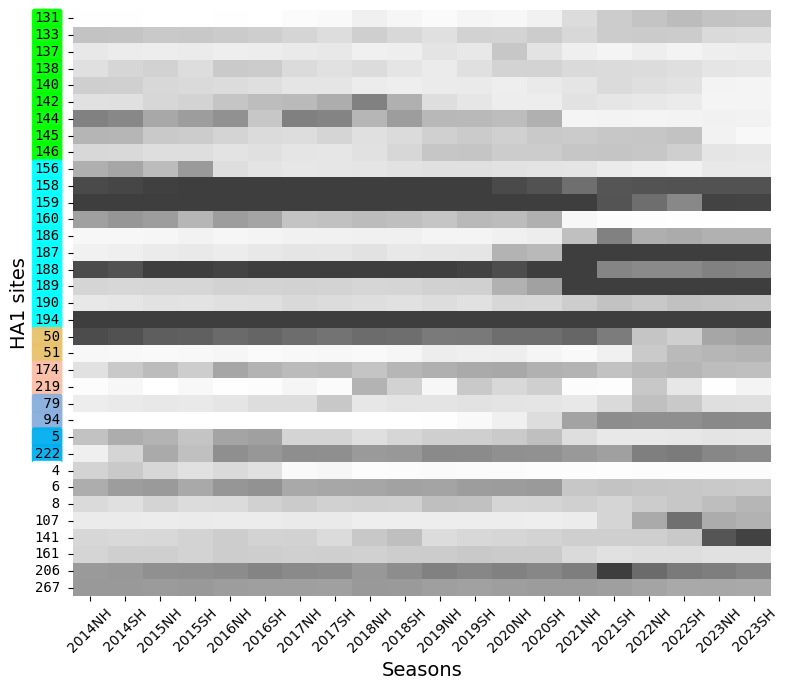

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

# --- 你的原始数据处理 ---
focus_epitope = [epitope + 16 for epitope in sorted_list]
df = pd.DataFrame(Site_scores, columns=seasons).iloc[focus_epitope]
df = df.apply(lambda x: np.where(x > 0.04, 0.04, x))
df.index = df.index - 16  # y 轴标签

plt.figure(figsize=(8, 7))
# cmap = sns.light_palette("seagreen", as_cmap=True)
cmap = mcolors.LinearSegmentedColormap.from_list(
    "white_to_gray", ["#ffffff", "#3e3e3e"], N=256
)

ax = sns.heatmap(df, annot=False, cmap=cmap, linewidths=0, cbar=False, vmin=df.min().min(), vmax=df.max().max())
ax.set_xlabel('Seasons', fontsize=14)
ax.set_ylabel('HA1 sites', fontsize=14)
ax.tick_params(axis='x', labelsize=10, rotation=45)
ax.tick_params(axis='y', pad=6)  # 给 bbox 留点空间

# ==== 关键：固定 bbox 宽度（等宽字体 + 补空格） ====
# 选定统一的字符宽度（你也可改成固定数字，如 fixed_len = 6）
raw_labels = [lab.get_text() for lab in ax.get_yticklabels()]
max_len = max(len(s) for s in raw_labels) if raw_labels else 0
fixed_len = max(3, max_len)  # 至少给 4 个字符宽，可按需调整

# 设置新的等宽标签 + bbox
new_labels = [s.rjust(fixed_len) for s in raw_labels]
ax.set_yticklabels(new_labels, fontfamily='monospace')  # 等宽字体确保宽度一致

colors = ["#00FF00", "#00FFFF", "#E8C16A", "#FBBEA7", "#88AEDD", '#00AEEF']
for lab in ax.get_yticklabels():
    this_site = int(lab.get_text())
    if this_site in epitope_A:
        this_color = colors[0]
    elif this_site in epitope_B:
        this_color = colors[1]
    elif this_site in epitope_C:
        this_color = colors[2]
    elif this_site in epitope_D:
        this_color = colors[3]
    elif this_site in epitope_E:
        this_color = colors[4]
    elif this_site in Unknown:
        this_color = colors[5]
    else:
        this_color = "white"

    lab.set_bbox(dict(
        facecolor=this_color, edgecolor="none",
        alpha=0.95, boxstyle="round,pad=0.2"
    ))

plt.tight_layout()
plt.savefig('HA1_sites.svg', format='svg', dpi=600, transparent=True)

#### 2.2.2 all site

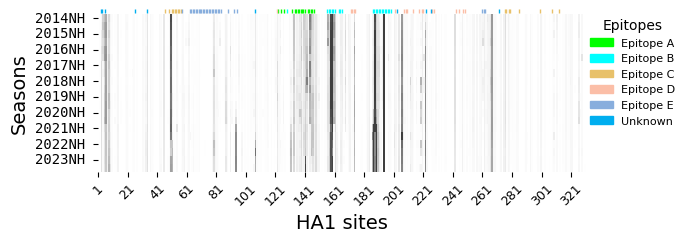

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

# --- 你的原始数据处理 ---
focus_epitope = range(17,347)
df = pd.DataFrame(Site_scores, columns=seasons).iloc[focus_epitope]
df = df.apply(lambda x: np.where(x > 0.04, 0.04, x))
df.index = df.index - 16  # y 轴标签

plt.figure(figsize=(7, 2.5))
# cmap = sns.light_palette("seagreen", as_cmap=True)
cmap = mcolors.LinearSegmentedColormap.from_list(
    "white_to_gray", ["#ffffff", "#3e3e3e"], N=256
)

ax = sns.heatmap(df.T, annot=False, cmap=cmap, linewidths=0, cbar=False, vmin=df.min().min(), vmax=df.max().max())
ax.set_xlabel('HA1 sites', fontsize=14)
ax.set_ylabel('Seasons', fontsize=14)
ax.tick_params(axis='x', labelsize=10, rotation=45)
ax.tick_params(axis='y', pad=6)  # 给 bbox 留点空间

# ==== 关键：固定 bbox 宽度（等宽字体 + 补空格） ====
# 选定统一的字符宽度（你也可改成固定数字，如 fixed_len = 6）
raw_labels = [lab.get_text() for lab in ax.get_yticklabels()]
max_len = max(len(s) for s in raw_labels) if raw_labels else 0
fixed_len = max(3, max_len)  # 至少给 4 个字符宽，可按需调整

# 设置新的等宽标签 + bbox
new_labels = [s.rjust(fixed_len) for s in raw_labels]
ax.set_yticklabels(new_labels, fontfamily='monospace')  # 等宽字体确保宽度一致

colors = ["#00FF00", "#00FFFF", "#E8C16A", "#FBBEA7", "#88AEDD", '#00AEEF']

# 在heatmap右侧添加连续区块颜色
for region, color in zip(
    [epitope_A, epitope_B, epitope_C, epitope_D, epitope_E, Unknown],
    ["#00FF00", "#00FFFF", "#E8C16A", "#FBBEA7", "#88AEDD", "#00AEEF"]
):
    for site in region:
        # 对每个单个位点绘制细色条
        ax.axvspan(site, site,  # -16 与 df.index 对齐
                   ymin=1.01, ymax=1.03,
                   color=color, transform=ax.get_yaxis_transform(), clip_on=False)

import matplotlib.patches as mpatches

# 定义颜色与名称对应
epitope_labels = ["Epitope A", "Epitope B", "Epitope C", "Epitope D", "Epitope E", "Unknown"]
epitope_colors = ["#00FF00", "#00FFFF", "#E8C16A", "#FBBEA7", "#88AEDD", "#00AEEF"]

# 为每个 epitope 生成一个矩形句柄
handles = [mpatches.Patch(color=c, label=l) for c, l in zip(epitope_colors, epitope_labels)]

# 添加图例
ax.legend(
    handles=handles,
    title="Epitopes",
    bbox_to_anchor=(1, 1),    # 放在图右上角外侧
    loc="upper left",
    borderaxespad=0.,
    frameon=False,
    fontsize=8
)
# 设置 x 轴刻度间隔为 10
step = 20
x_ticks = np.arange(0, len(df.index), step)
x_labels = [str(df.index[i]) for i in x_ticks]
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, rotation=45, fontsize=9)

plt.tight_layout()
plt.savefig('../../Figure/Fig S2/HA1_sites_all.svg', format='svg', dpi=600, transparent=True)

#### 2.2.3 epitope

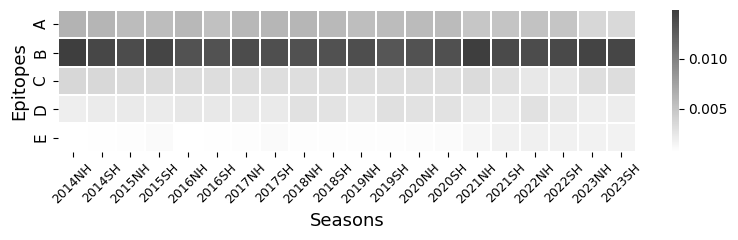

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

# 定义各表位的位点索引
epitopes = {
    "A": epitope_A,
    "B": epitope_B,
    "C": epitope_C,
    "D": epitope_D,
    "E": epitope_E
}

# 原始数据
focus_epitope = range(17, 345)
df = pd.DataFrame(Site_scores, columns=seasons).iloc[focus_epitope]
df.index = df.index - 16

# === 聚合每个表位的平均分数 ===
grouped = {}
for name, sites in epitopes.items():
    valid_sites = [s for s in sites if s in df.index]
    if len(valid_sites) > 0:
        grouped[name] = df.loc[valid_sites].mean(axis=0)
agg_df = pd.DataFrame(grouped).T  # 表位为行，季节为列

# === 绘图 ===
plt.figure(figsize=(8, 2.5))
cmap = mcolors.LinearSegmentedColormap.from_list(
    "white_to_gray", ["#ffffff", "#3e3e3e"], N=256
)

ax = sns.heatmap(
    agg_df,
    cmap=cmap,
    linewidths=0.3,
    cbar=True,
    vmin=agg_df.min().min(),
    vmax=agg_df.max().max(),
    annot=False
)

ax.set_xlabel('Seasons', fontsize=13)
ax.set_ylabel('Epitopes', fontsize=13)
ax.tick_params(axis='x', labelrotation=45, labelsize=9)
ax.tick_params(axis='y', labelsize=11)

plt.tight_layout()
plt.savefig('../../Figure/Fig S2/HA1_epitope_grouped.svg', format='svg', dpi=600, transparent=True)


## 3. NA protein

### 3.0 Load data

In [ ]:
data_dir = "/mnt/zzbnew/peixunban/chenyihao/attention_prob_H1N1"
files = [f"{data_dir}/{i}.pth" for i in range(4, 405, 4)]

def load_file(path):
    return torch.load(path, map_location="cpu", weights_only=True)

max_workers = min(8, multiprocessing.cpu_count())

attention_prob = [None] * len(files)
with ThreadPoolExecutor(max_workers=max_workers) as executor:
    futures = {executor.submit(load_file, f): idx for idx, f in enumerate(files)}
    for future in tqdm(as_completed(futures), total=len(futures)):
        idx = futures[future]
        attention_prob[idx] = future.result()

long_list = [t for tensor in attention_prob for t in tensor]
virusNAtensor = torch.stack(long_list).detach().numpy()


 55%|█████▌    | 56/101 [00:43<00:15,  2.97it/s]

### 3.1 diversity

In [33]:
# # 初始化一个空列表，用于存储每个位置上的字符多样性
series = Inference_data_final['seq_d']
diversity_list = []

# 遍历字符串的每个位置
for i in range(len(series.iloc[0])):
    chars = series.apply(lambda x: x[i])
    mean = chars.value_counts().mean()
    std = chars.value_counts().std()
    diversity = std / mean if mean != 0 else 0
    diversity_list.append(diversity)

for i in range(len(diversity_list)):
    if np.isnan(diversity_list[i]):
        diversity_list[i] = 0

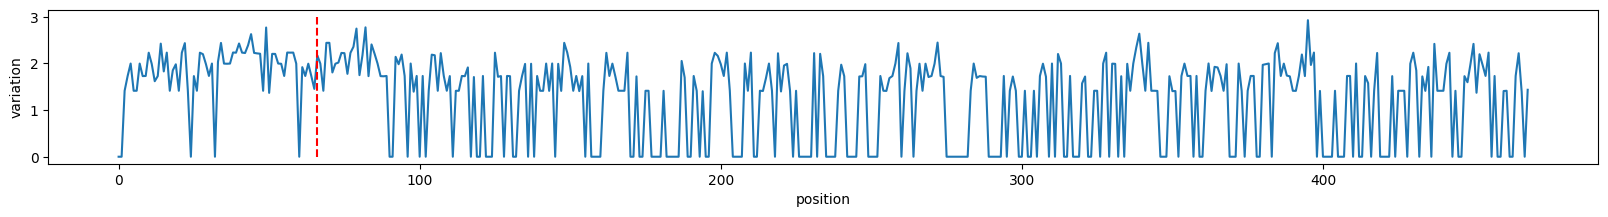

In [38]:
plt.figure(figsize=(20, 2))
plt.plot(diversity_list)
plt.xlabel('position')
plt.ylabel('variation')
plt.vlines(x=66, ymin=0, ymax=3, colors='red', linestyles='dashed')

### 3.2 key sites

In [8]:
seasons = ['2014NH', '2014SH', '2015NH','2015SH', '2016NH', '2016SH', 
           '2017NH', '2017SH', '2018NH','2018SH', '2019NH', '2019SH', '2020NH', '2020SH', '2021NH', '2021SH', 
           '2022NH', '2022SH', '2023NH', '2023SH']
           
# 一次性计算第三维均值
virus_mean = virusNAtensor.mean(2)  
# 预先转换为数组
virus_dates = np.array(Inference_data_final['virusDate'])
# 初始化输出矩阵（假设virusHAtensor.shape[1]是site维度）
n_sites = virus_mean.shape[1]
Site_scores = np.zeros((n_sites, len(seasons)))

# 向量化循环
for i, season in enumerate(seasons):
    mask = (virus_dates == season)
    if not np.any(mask):
        continue
    Site_scores[:, i] = virus_mean[mask].mean(0)


In [9]:
Sites_origin = []
for i in range(Site_scores.shape[1]):
    site = get_top_k_indices(Site_scores[83:469,i], k=1)
    site = [item + 83 for item in site]
    Sites_origin = Sites_origin + site

Sites = sorted(set(Sites_origin))
print(Sites)
print(len(Sites))

[88, 200, 314, 366, 389, 394]
6


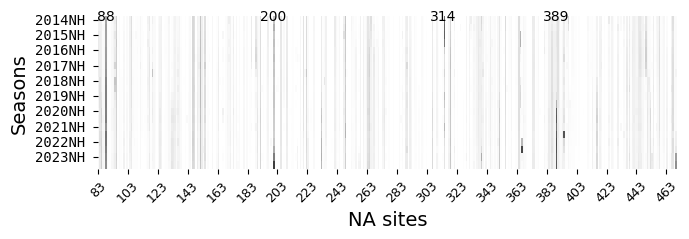

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

# --- 你的原始数据处理 ---
focus_epitope = range(83,470)
df = pd.DataFrame(Site_scores, columns=seasons).iloc[focus_epitope]
# df = df.apply(lambda x: np.where(x > 0.04, 0.04, x))
df.index = df.index  # y 轴标签

plt.figure(figsize=(7, 2.5))
# cmap = sns.light_palette("seagreen", as_cmap=True)
cmap = mcolors.LinearSegmentedColormap.from_list(
    "white_to_gray", ["#ffffff", "#3e3e3e"], N=256
)

ax = sns.heatmap(df.T, annot=False, cmap=cmap, linewidths=0, cbar=False, vmin=df.min().min(), vmax=df.max().max())
ax.set_xlabel('NA sites', fontsize=14)
ax.set_ylabel('Seasons', fontsize=14)
ax.tick_params(axis='x', labelsize=10, rotation=45)
ax.tick_params(axis='y', pad=6)  # 给 bbox 留点空间

# ==== 关键：固定 bbox 宽度（等宽字体 + 补空格） ====
# 选定统一的字符宽度（你也可改成固定数字，如 fixed_len = 6）
raw_labels = [lab.get_text() for lab in ax.get_yticklabels()]
max_len = max(len(s) for s in raw_labels) if raw_labels else 0
fixed_len = max(3, max_len)  # 至少给 4 个字符宽，可按需调整

# 设置新的等宽标签 + bbox
new_labels = [s.rjust(fixed_len) for s in raw_labels]
ax.set_yticklabels(new_labels, fontfamily='monospace')  # 等宽字体确保宽度一致
ax.annotate('88', xy=(0, 0), xytext=(88-83, 0), fontsize=10, ha='center', va='center')
ax.annotate('200', xy=(0, 0), xytext=(200-83, 0), fontsize=10, ha='center', va='center')
ax.annotate('314', xy=(0, 0), xytext=(314-83, 0), fontsize=10, ha='center', va='center')
ax.annotate('389', xy=(0, 0), xytext=(389-83, 0), fontsize=10, ha='center', va='center')



# 设置 x 轴刻度间隔为 10
step = 20
x_ticks = np.arange(0, len(df.index), step)
x_labels = [str(df.index[i]) for i in x_ticks]
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, rotation=45, fontsize=9)

plt.tight_layout()
plt.savefig('NA_sites.svg', format='svg', dpi=600, transparent=True)

In [12]:
Inference_data_final['seq_d'].str[87:90].value_counts()

seq_d
NSS    19966
NFS       62
SSS       34
NST       12
KSS        6
NPS        3
NSY        3
Name: count, dtype: int64

In [10]:
Inference_data_final['seq_d'].str[87].value_counts()

seq_d
N    20046
S       34
K        6
Name: count, dtype: int64

In [46]:
Inference_data_final['seq_d'].str[199].value_counts()

seq_d
S    18020
N     2034
I       13
R        9
X        6
G        4
Name: count, dtype: int64

In [47]:
Inference_data_final['seq_d'].str[313].value_counts()

seq_d
M    16723
I     3316
T       17
V       14
X       12
K        4
Name: count, dtype: int64

In [48]:
Inference_data_final['seq_d'].str[388].value_counts()

seq_d
I    11907
K     8082
R       32
T       22
M       16
X       14
V       13
Name: count, dtype: int64

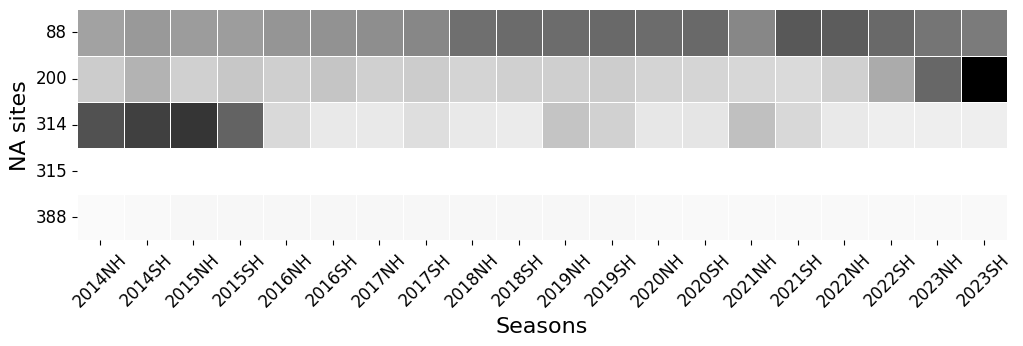

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
# focus_epitope = [epitope + 16 for epitope in epitope_in_HA1]
# df = pd.DataFrame(combined_array, columns=seasons).iloc[focus_epitope]
# dd = [87,88,89,199,200,201,313,314,315,388,389,390]
dd = [88,200,314,315,388]
df = pd.DataFrame(Site_scores, columns=seasons).iloc[dd]
df = df.apply(lambda x: np.where(x > 0.04, 0.04, x))

# 绘制热图
plt.figure(figsize=(12, 3))
cmap = sns.color_palette("Greys", as_cmap=True)
sns.heatmap(df, annot=False, cmap=cmap, linewidths=.5, cbar=False)  # 设置色标标签的字体大小


# 添加标题和标签
plt.xlabel('Seasons', fontsize=16)
plt.ylabel('NA sites', fontsize=16)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12, rotation=0)
# plt.legend(fontsize=12)
plt.savefig('NA_sites.svg', dpi=300, transparent=True)


In [108]:
period = [str(year)+hemisphere for year in range(2014,2021) for hemisphere in ['NH','SH']]
Inference_data_final.loc[Inference_data_final['virusDate'].isin(period),'seq_d'].str[389-1].value_counts()

seq_d
I    10868
K     3941
M       16
V       10
R        9
X        7
T        4
Name: count, dtype: int64

In [109]:
Inference_data_final['seq_d'].str[314-1].value_counts()

seq_d
M    16723
I     3316
T       17
V       14
X       12
K        4
Name: count, dtype: int64

In [29]:
Inference_data_final['seq_d'].str[87].value_counts()

seq_d
N    20046
S       34
K        6
Name: count, dtype: int64

In [39]:
(Inference_data_final['seq_d'].str[70:74] + '+' + Inference_data_final['seq_d'].str[87]).value_counts()

seq_d
NTNS+N    8059
NTNF+N    8013
NINF+N    2193
NNNS+N     760
NTNL+N     568
NINS+N     144
NTNY+N      77
NTDS+N      26
NTNP+N      25
NINL+N      24
NINF+S      22
NTNX+N      15
HTNS+N      14
NTNV+N      13
NTNF+S      12
NIDF+N      12
NNNP+N       9
KTNS+N       8
TINF+N       8
XNNS+N       8
SINF+N       8
NVNS+N       7
NTHS+N       7
NLNF+N       6
NTNF+K       6
SINS+N       6
NVNF+N       6
NTNT+N       6
NTKS+N       6
NTNC+N       6
NTNI+N       5
STNS+N       4
XTNF+N       3
Name: count, dtype: int64

In [120]:
from collections import Counter

# 假设我们有以下列表

# 使用Counter来统计每个独立值的个数
count = Counter(Sites_origin)

# 打印统计结果
print(count)

Counter({27: 20, 218: 20, 44: 20, 28: 20, 356: 20, 321: 20, 10: 20, 380: 15, 204: 11, 313: 8, 203: 7, 323: 7, 447: 6, 449: 5, 130: 1})
